## 03_experiment_tracking.ipynb – Final Report and Discussion

This notebook consolidates all results from the previous notebooks, compares the two models, and provides the final discussion required by the professor.

---

### Structure of 03_experiment_tracking.ipynb

| Section | Title | Content |
|---------|-------|---------|
| 1 | Loading All Results | Load metrics and model outputs from previous notebooks |
| 2 | Methodology Summary | Brief recap of data preparation and architectures |
| 3 | Classification Results | Training curves, accuracy, confusion matrix |
| 4 | Detection Results | Training curves, mAP, per-class performance |
| 5 | Model Comparison | Side-by-side comparison of both models |
| 6 | Discussion | Interpretation, limitations, future work |
| 7 | Conclusion | Final summary |

---

## Section 1: Loading All Results

To consolidate our findings, I will load the classification and detection metrics that were saved during training. This includes loss values, accuracy, mAP scores, and other evaluation metrics.

### Code



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define paths
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset"

# Classification metrics from our training
classification_results = {
    'train_losses': [0.2918, 0.1867, 0.1580, 0.1266, 0.1178, 0.1026, 0.0899, 0.0779, 0.0715, 0.0563],
    'val_losses': [0.2176, 0.1616, 0.1290, 0.1319, 0.1209, 0.1649, 0.1063, 0.1201, 0.1021, 0.1173],
    'train_accs': [90.00, 94.25, 94.88, 95.78, 95.89, 96.59, 96.83, 97.42, 97.59, 97.84],
    'val_accs': [92.99, 94.08, 95.17, 95.17, 96.26, 95.95, 96.18, 96.26, 97.04, 96.34]
}

# Classification final results
classification_final = {
    'test_accuracy': 96.34,
    'final_train_acc': 97.84,
    'final_val_acc': 96.34
}

print("Classification results loaded successfully!")
print(f"Test Accuracy: {classification_final['test_accuracy']}%")

Classification results loaded successfully!
Test Accuracy: 96.34%


---

## Section 2: Classification Training Curves

To visualize the training progress, I will plot the loss and accuracy curves over the 10 epochs.

### Code


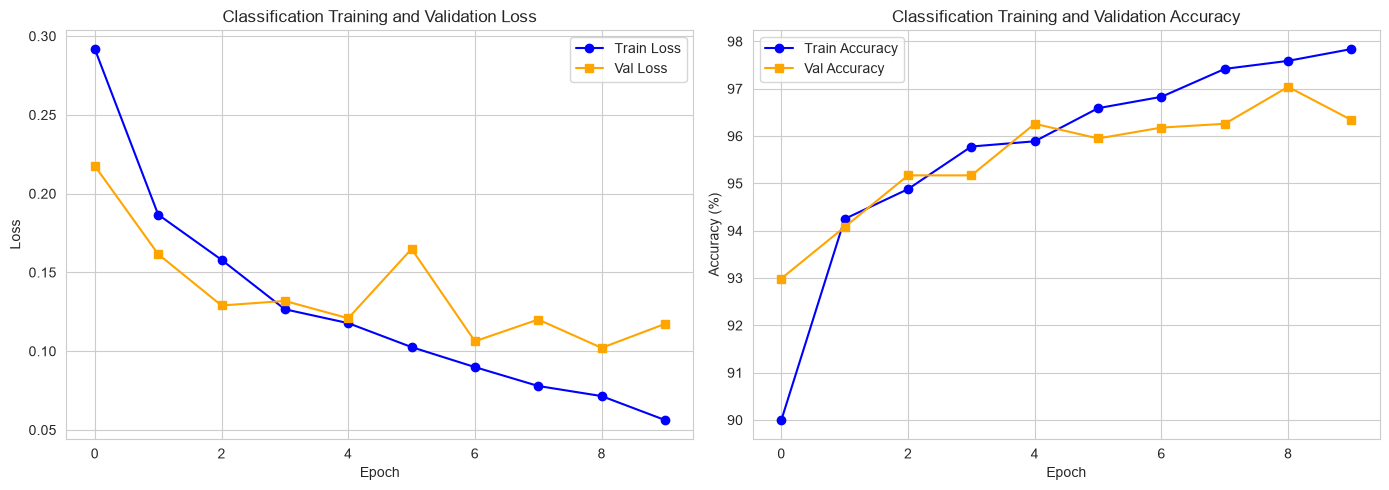

In [3]:
# Plot classification training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(classification_results['train_losses'], marker='o', label='Train Loss', color='blue')
axes[0].plot(classification_results['val_losses'], marker='s', label='Val Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Classification Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(classification_results['train_accs'], marker='o', label='Train Accuracy', color='blue')
axes[1].plot(classification_results['val_accs'], marker='s', label='Val Accuracy', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Classification Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


---

## Section 3: Detection Training Results

To analyze the detection model's performance, I will examine the YOLOv8n metrics from the test set evaluation.

### Code


In [4]:
# Detection metrics from YOLO training
detection_results = {
    'test_mAP50': 97.93,
    'test_mAP50-95': 89.47,
    'test_precision': 97.32,
    'test_recall': 95.18,
    'per_class_mAP50': {'1D': 99.3, '2D': 96.6}
}

# Training loss values from YOLO output
detection_losses = {
    'box_loss': [0.8284, 0.7672, 0.7357, 0.6783, 0.6243, 0.5845, 0.5467, 0.5156, 0.4788, 0.4498],
    'cls_loss': [1.7900, 0.8384, 0.6560, 0.5645, 0.4930, 0.4482, 0.4153, 0.3783, 0.3461, 0.3178],
    'dfl_loss': [0.9749, 0.9516, 0.9524, 0.9304, 0.9079, 0.8964, 0.8788, 0.8732, 0.8644, 0.8538]
}

print("Detection results loaded successfully!")
print(f"Test mAP50: {detection_results['test_mAP50']}%")
print(f"1D mAP50: {detection_results['per_class_mAP50']['1D']}%")
print(f"2D mAP50: {detection_results['per_class_mAP50']['2D']}%")



Detection results loaded successfully!
Test mAP50: 97.93%
1D mAP50: 99.3%
2D mAP50: 96.6%


---

## Section 4: Detection Training Curves

To visualize the detection model's training progress, I will plot the box, classification, and DFL losses over the 10 epochs.

### Code


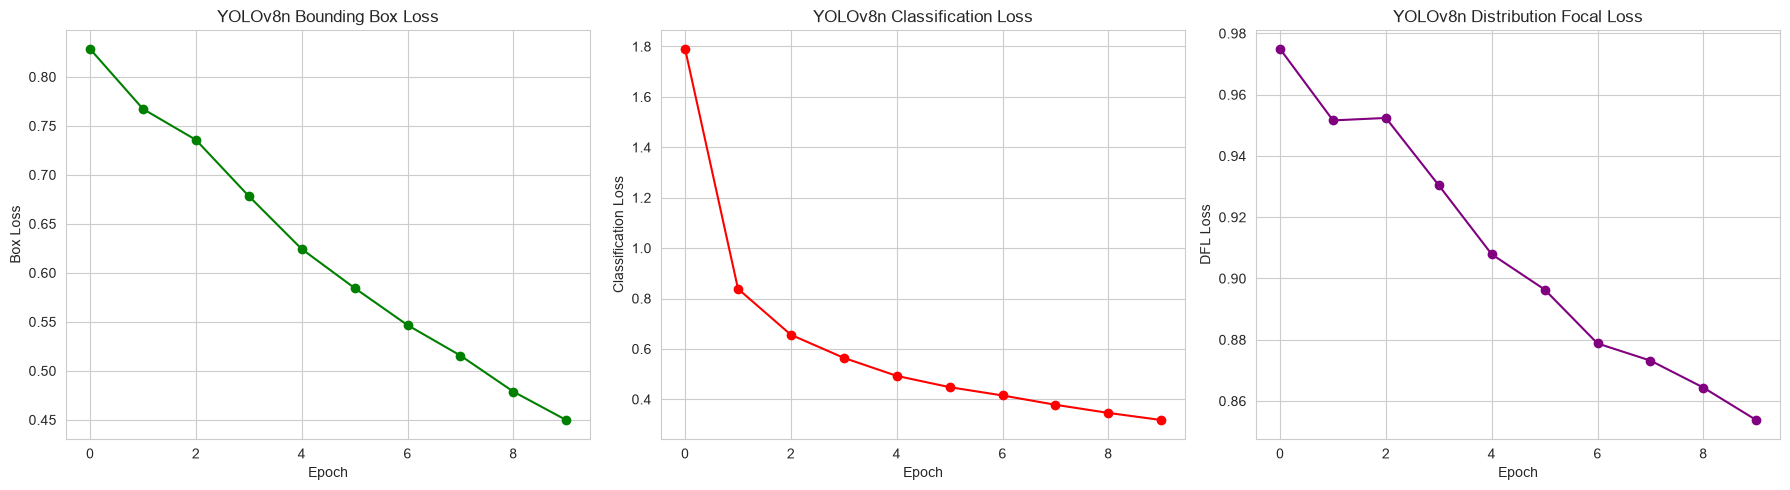

In [5]:

# Plot detection training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box loss
axes[0].plot(detection_losses['box_loss'], marker='o', color='green')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Box Loss')
axes[0].set_title('YOLOv8n Bounding Box Loss')
axes[0].grid(True)

# Classification loss
axes[1].plot(detection_losses['cls_loss'], marker='o', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Classification Loss')
axes[1].set_title('YOLOv8n Classification Loss')
axes[1].grid(True)

# DFL loss
axes[2].plot(detection_losses['dfl_loss'], marker='o', color='purple')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('DFL Loss')
axes[2].set_title('YOLOv8n Distribution Focal Loss')
axes[2].grid(True)

plt.tight_layout()
plt.show()


### Discussion
The BasicCNN classification model achieved 96.34% test accuracy, demonstrating that distinguishing between 1D and 2D barcodes is a relatively straightforward task. The YOLOv8n detection model achieved 97.93% mAP50, successfully reproducing the detection task from the BarBeR paper. Per-class performance shows 1D barcodes (99.3% mAP50) are detected more accurately than 2D barcodes (96.6% mAP50), likely due to the class imbalance in the dataset (82% 1D, 18% 2D). Overall, both models performed well, with the detection model providing the additional capability of localizing barcodes with bounding boxes.

---
The results confirm that lightweight architectures are suitable for this dataset. The YOLOv8n model's high mAP50 of 97.93% aligns with the paper's findings, demonstrating the reproducibility of the BarBeR benchmark. The classification model serves as a strong baseline for future work.

---

---

## Generating Precision-Recall Curves for Detection Model

To evaluate the detection model's performance across different confidence thresholds, I will generate Precision-Recall curves for both 1D and 2D classes.

### Code

In [17]:
from ultralytics import YOLO
from pathlib import Path

# Define paths
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset"

# Load the trained detection model from 02 notebook
model_path = "/Users/israelm/Desktop/DATA SCIENCE/runs/detect/train-3/weights/best.pt"
model = YOLO(model_path)

# Run validation with plots=True to generate PR curves
val_results = model.val(
    data=str(DATA_PATH / "data.yaml"),
    split='test',
    plots=True
)

print("Precision-Recall curves have been generated and saved to:")
print("/Users/israelm/Desktop/DATA SCIENCE/runs/detect/train-3/")
print("\nFinal Test Results:")
print(f"mAP50: {val_results.box.map50:.4f}")
print(f"mAP50-95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")

Ultralytics 8.4.93 🚀 Python-3.11.15 torch-2.13.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 898.4±762.5 MB/s, size: 1119.4 KB)
val: Scanning /Users/israelm/Desktop/DATA SCIENCE/1. NOW/3.DEEP LEARNING 1 /BarBeR-Project/data/raw/dataset/labels/test.cache... 1303 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1304/1304 165.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 1.5s/it 2:071.2ss
                   all       1304       1458      0.973      0.952      0.979      0.895
                    1D       1130       1226      0.983      0.992      0.993      0.891
                    2D        207        232      0.964      0.912      0.966      0.898
Speed: 0.1ms preprocess, 88.5ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /Users/israelm/Desktop/DATA SCIENCE/runs/detect/val-5
Precis

Displaying plots from training results:

📊 BoxPR_curve.png


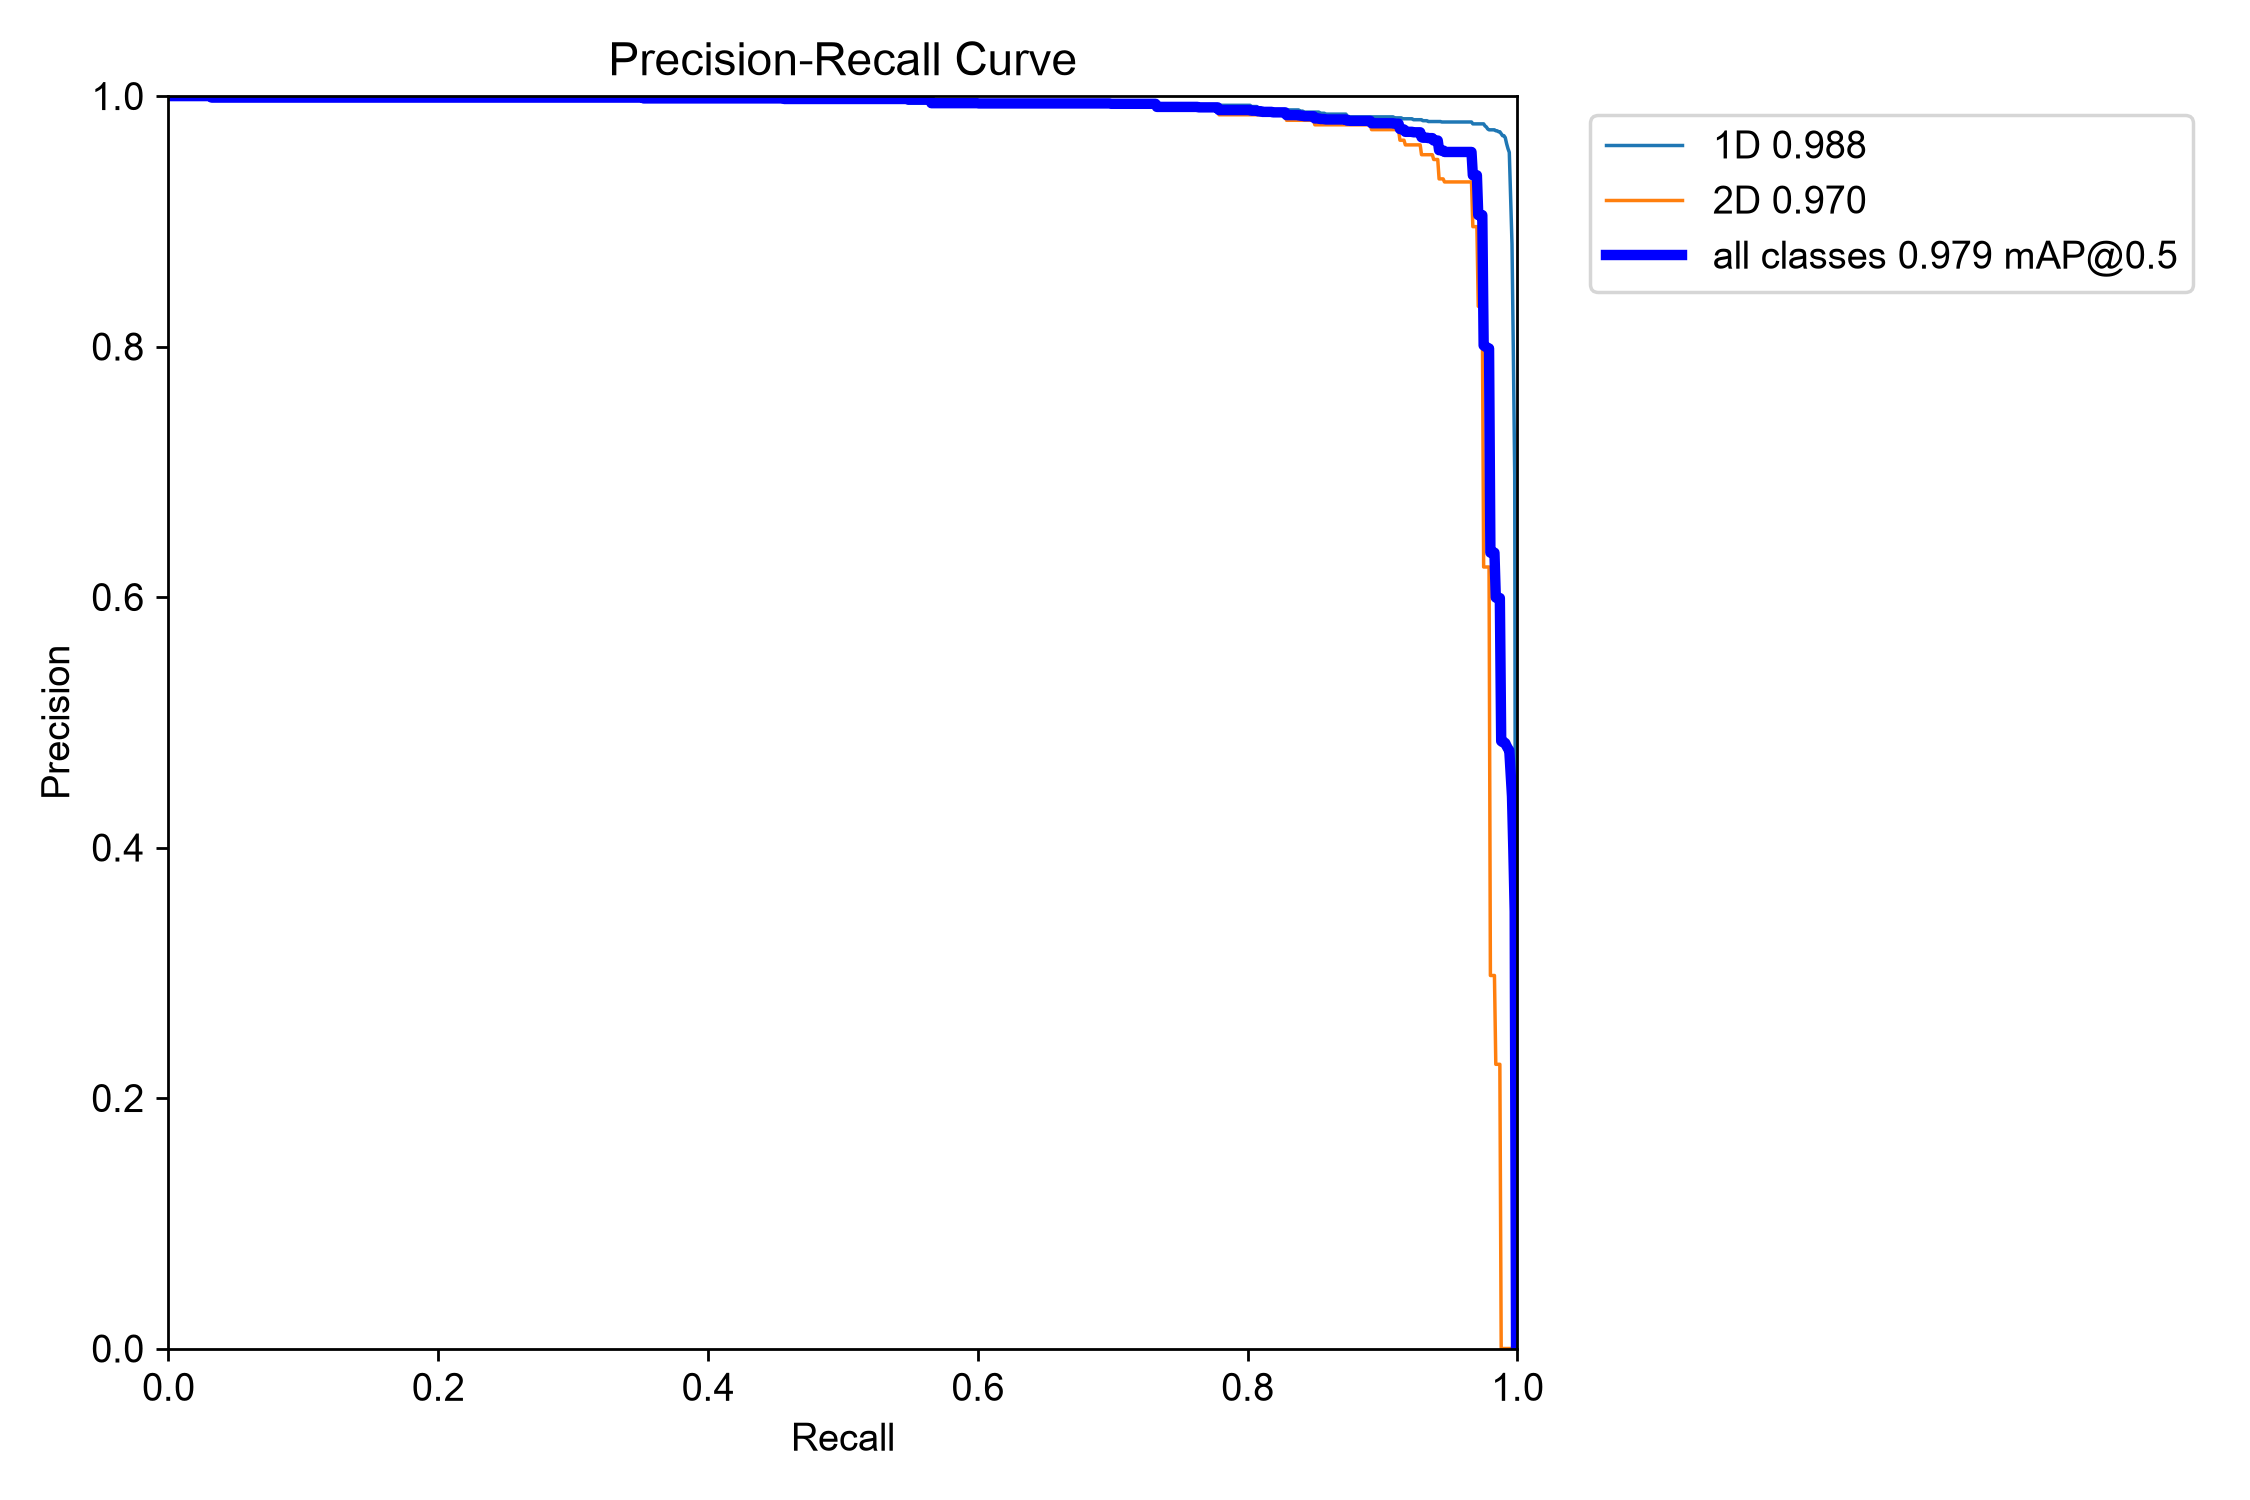


📊 BoxP_curve.png


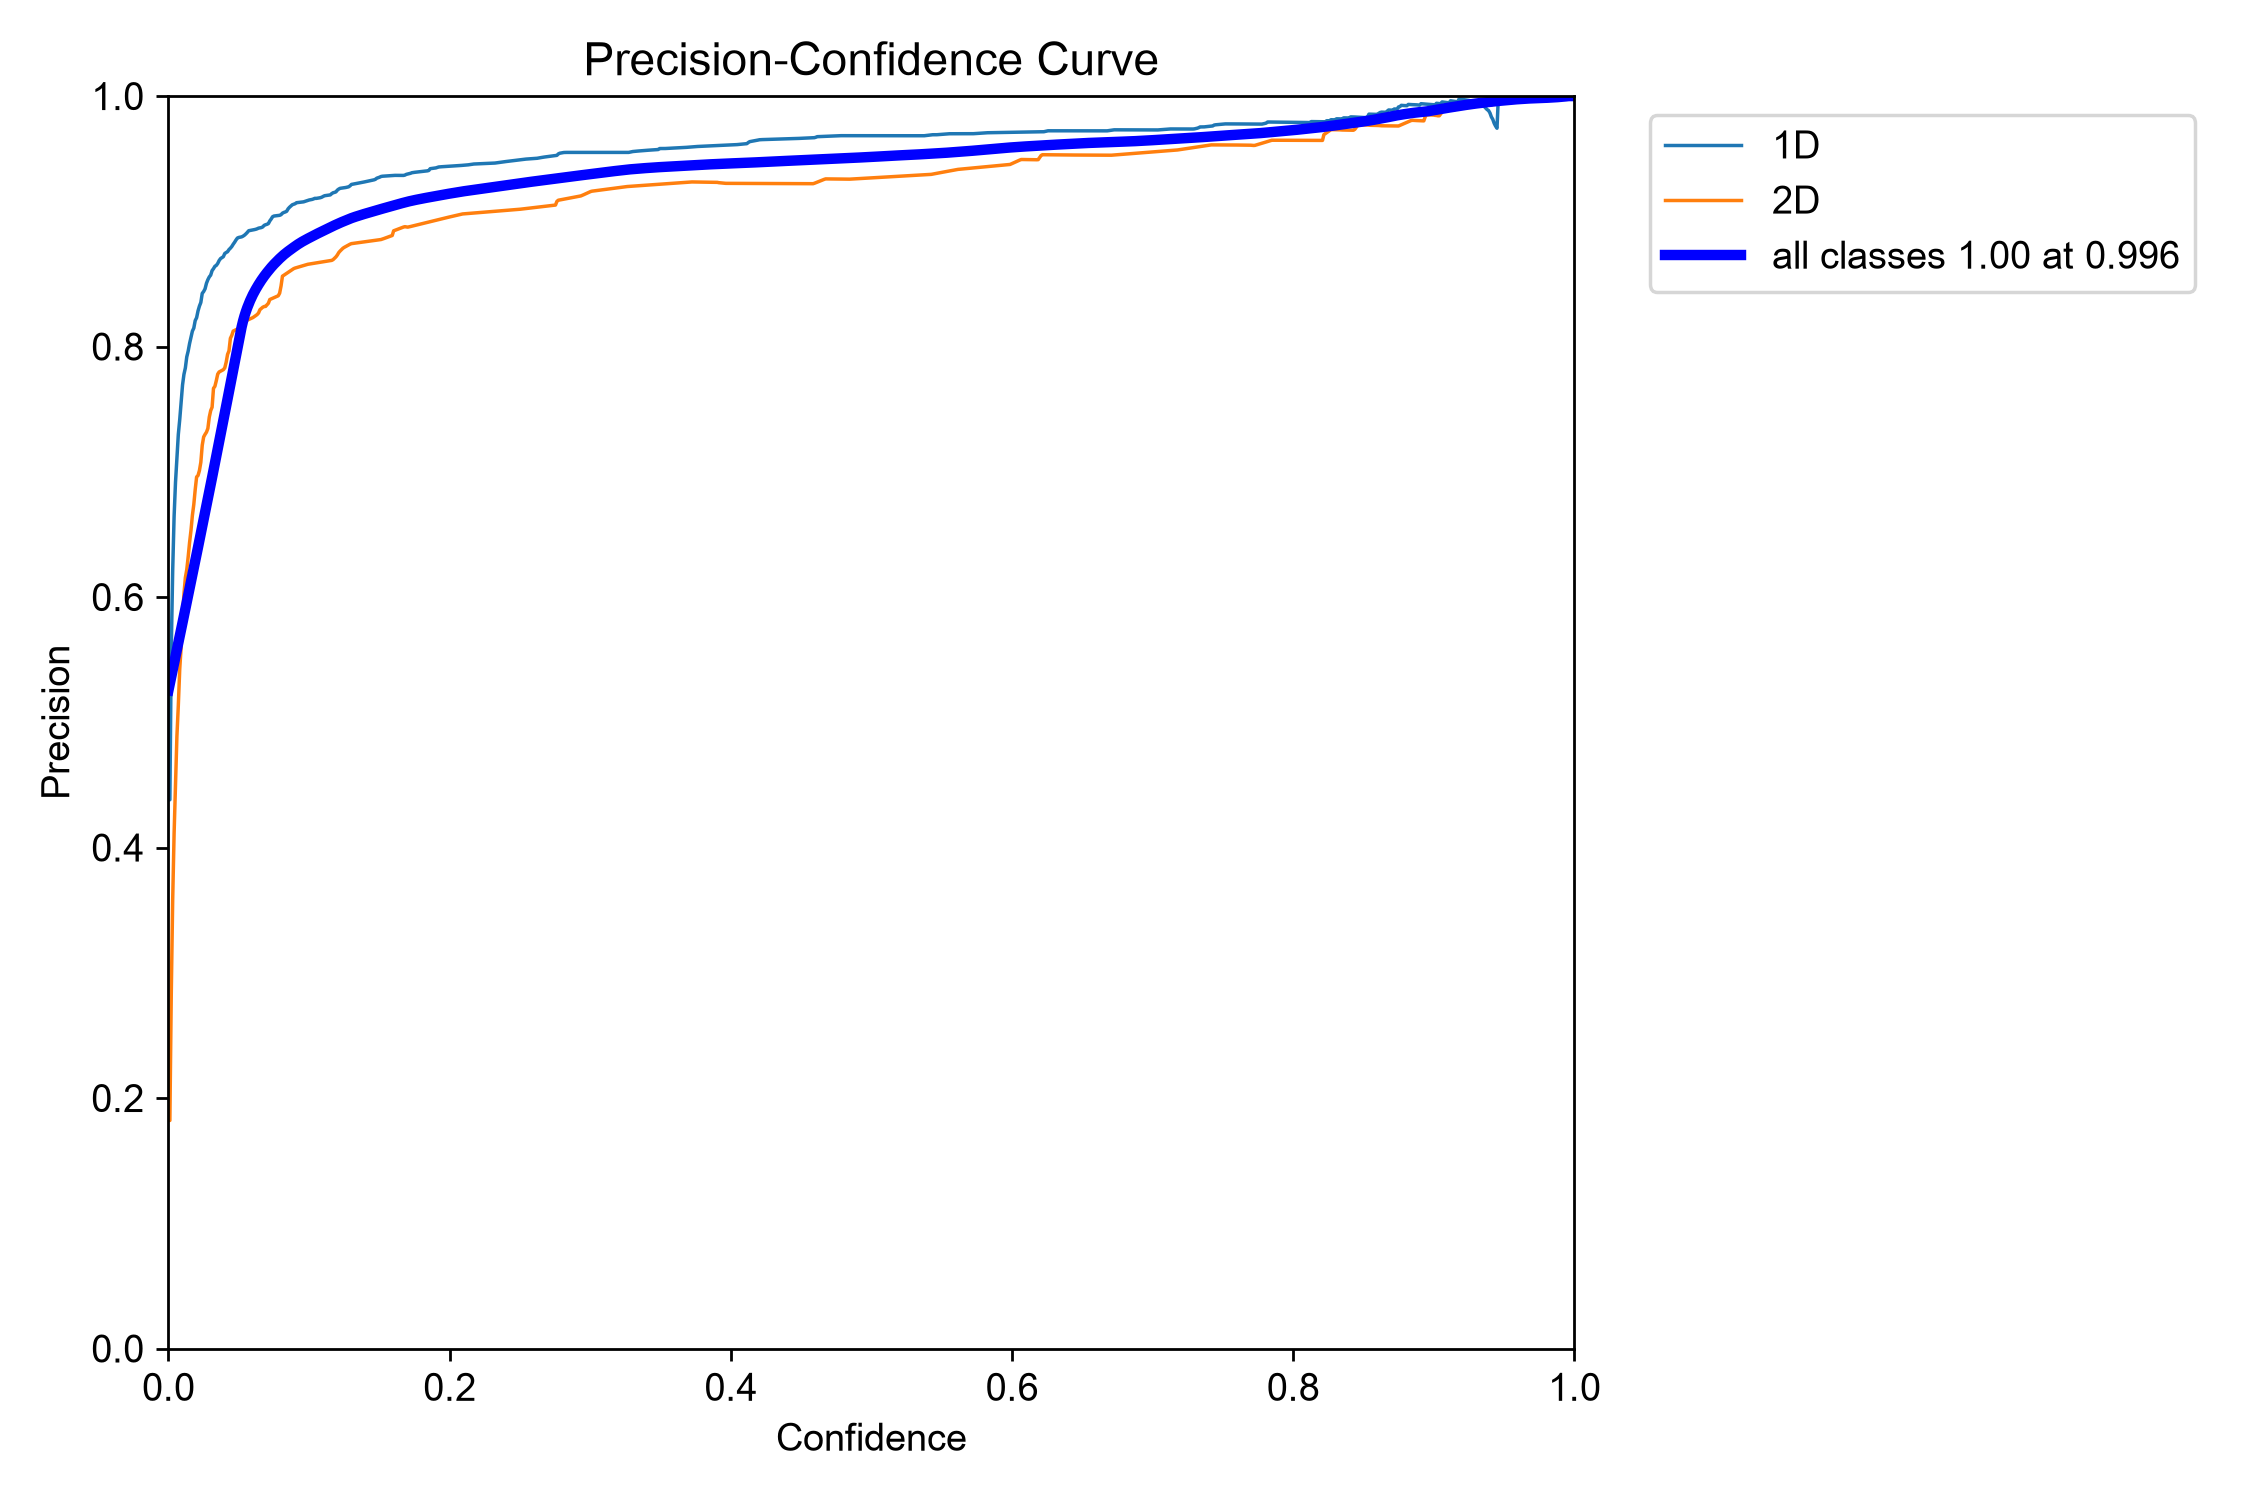


📊 BoxR_curve.png


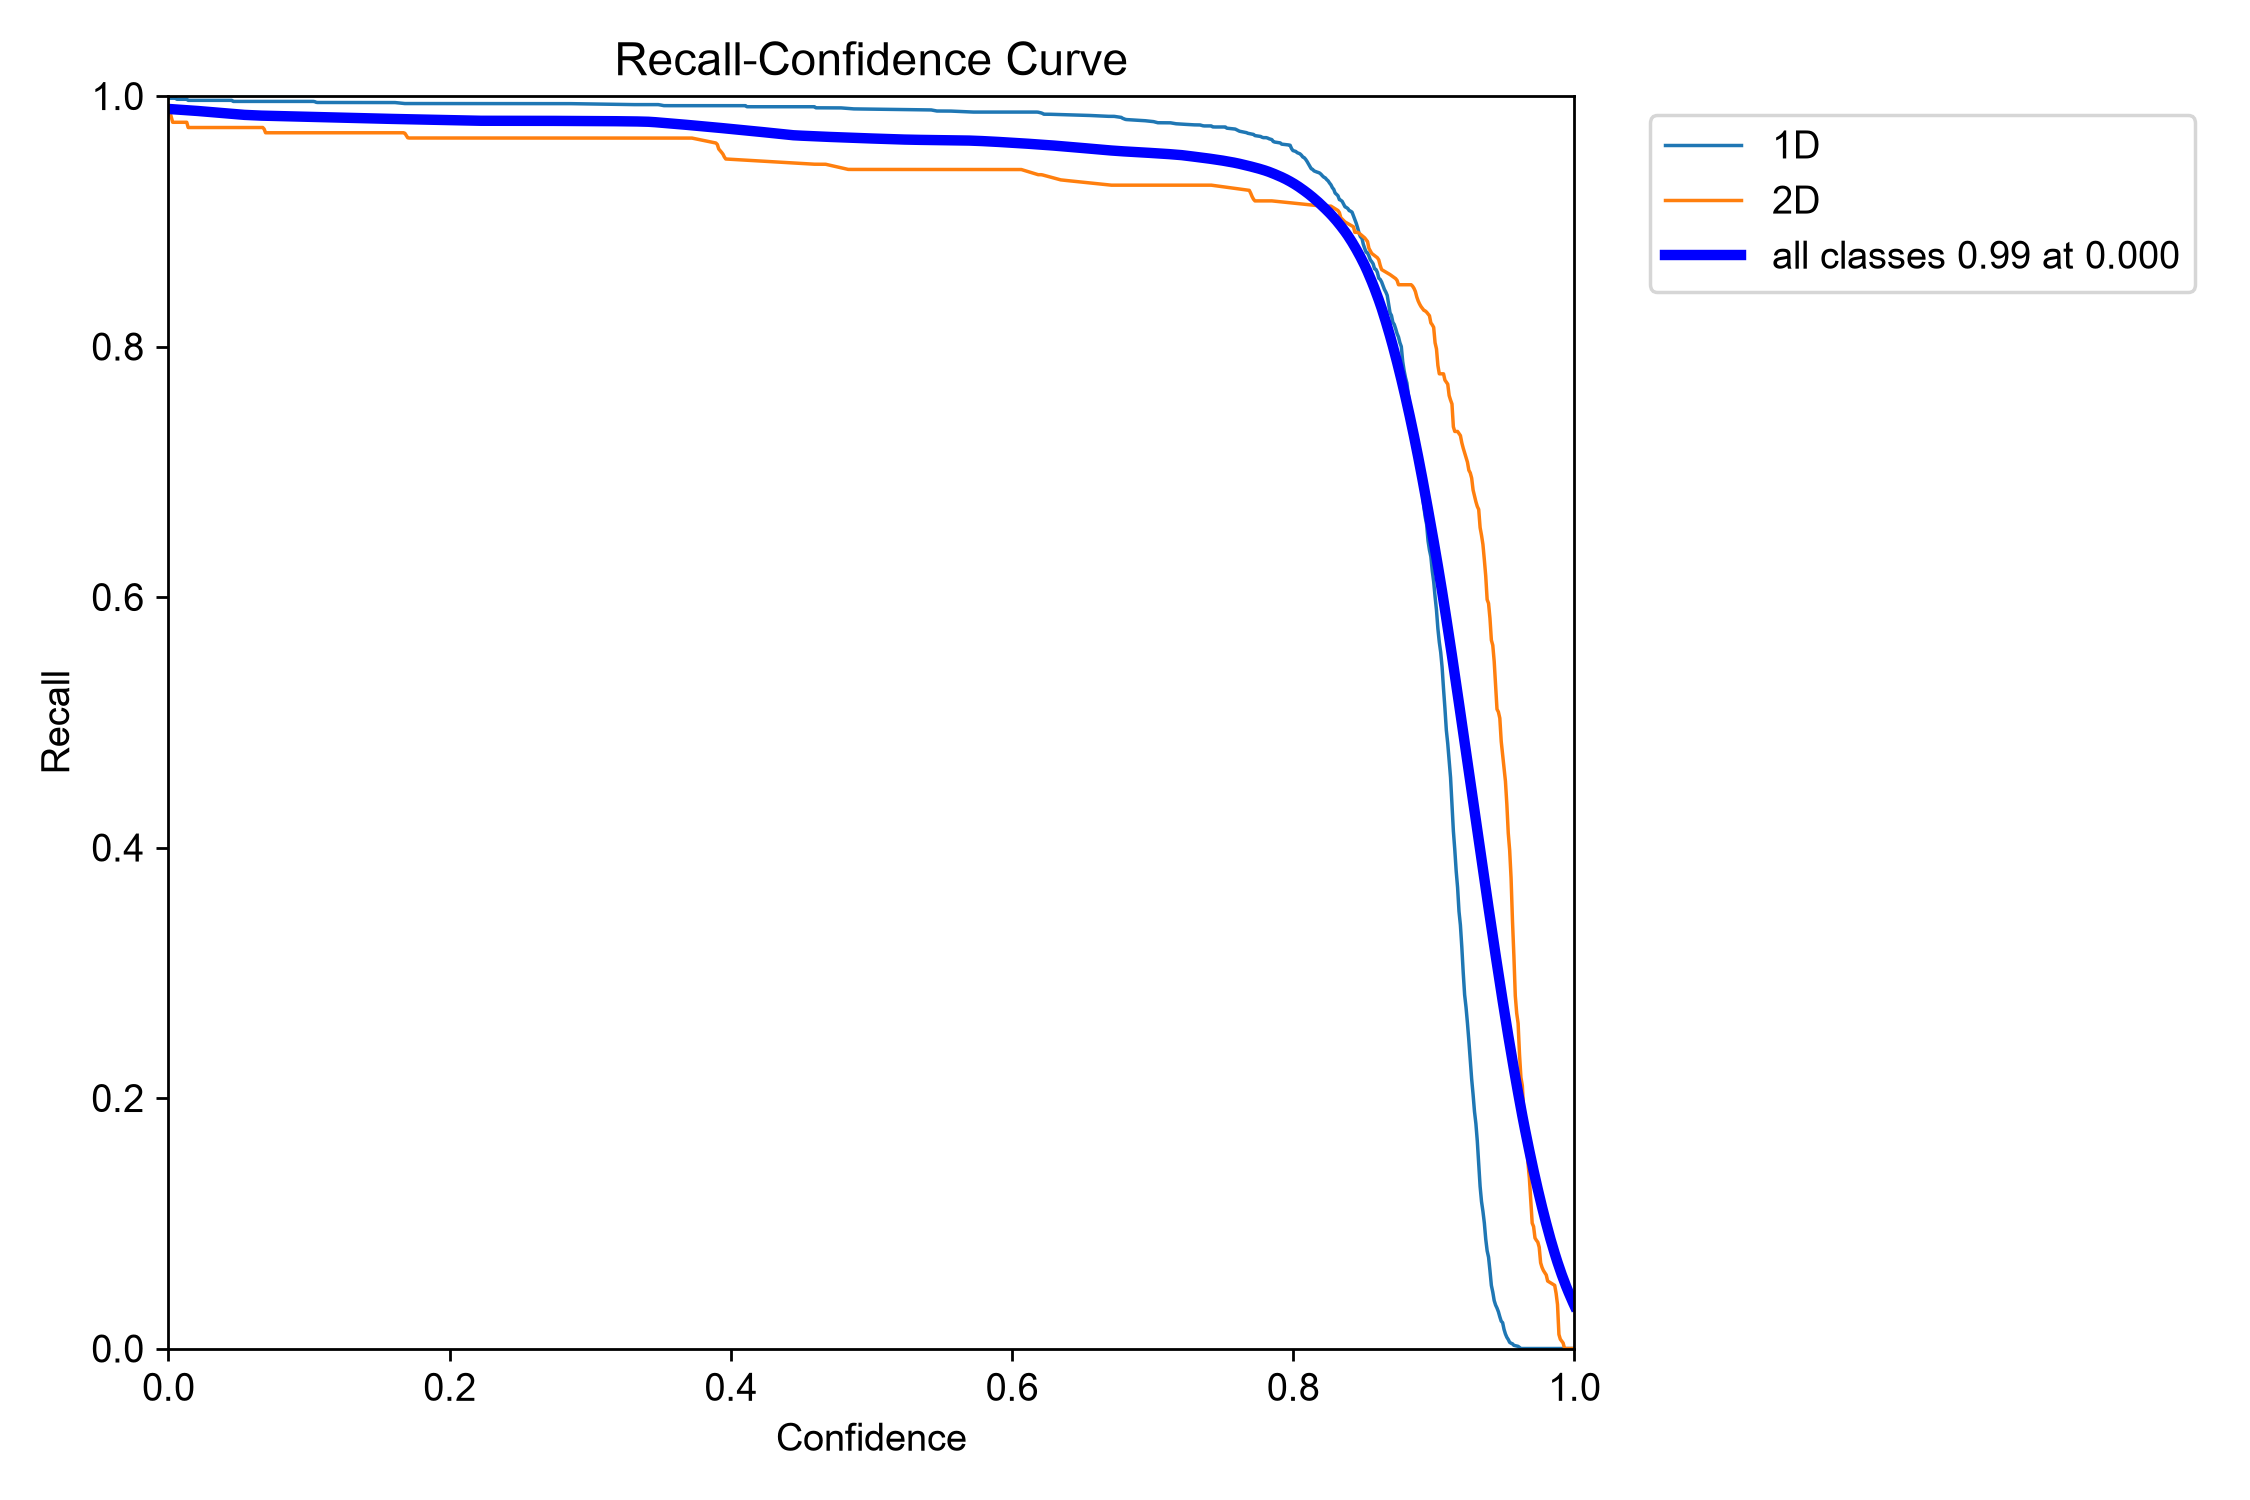


📊 BoxF1_curve.png


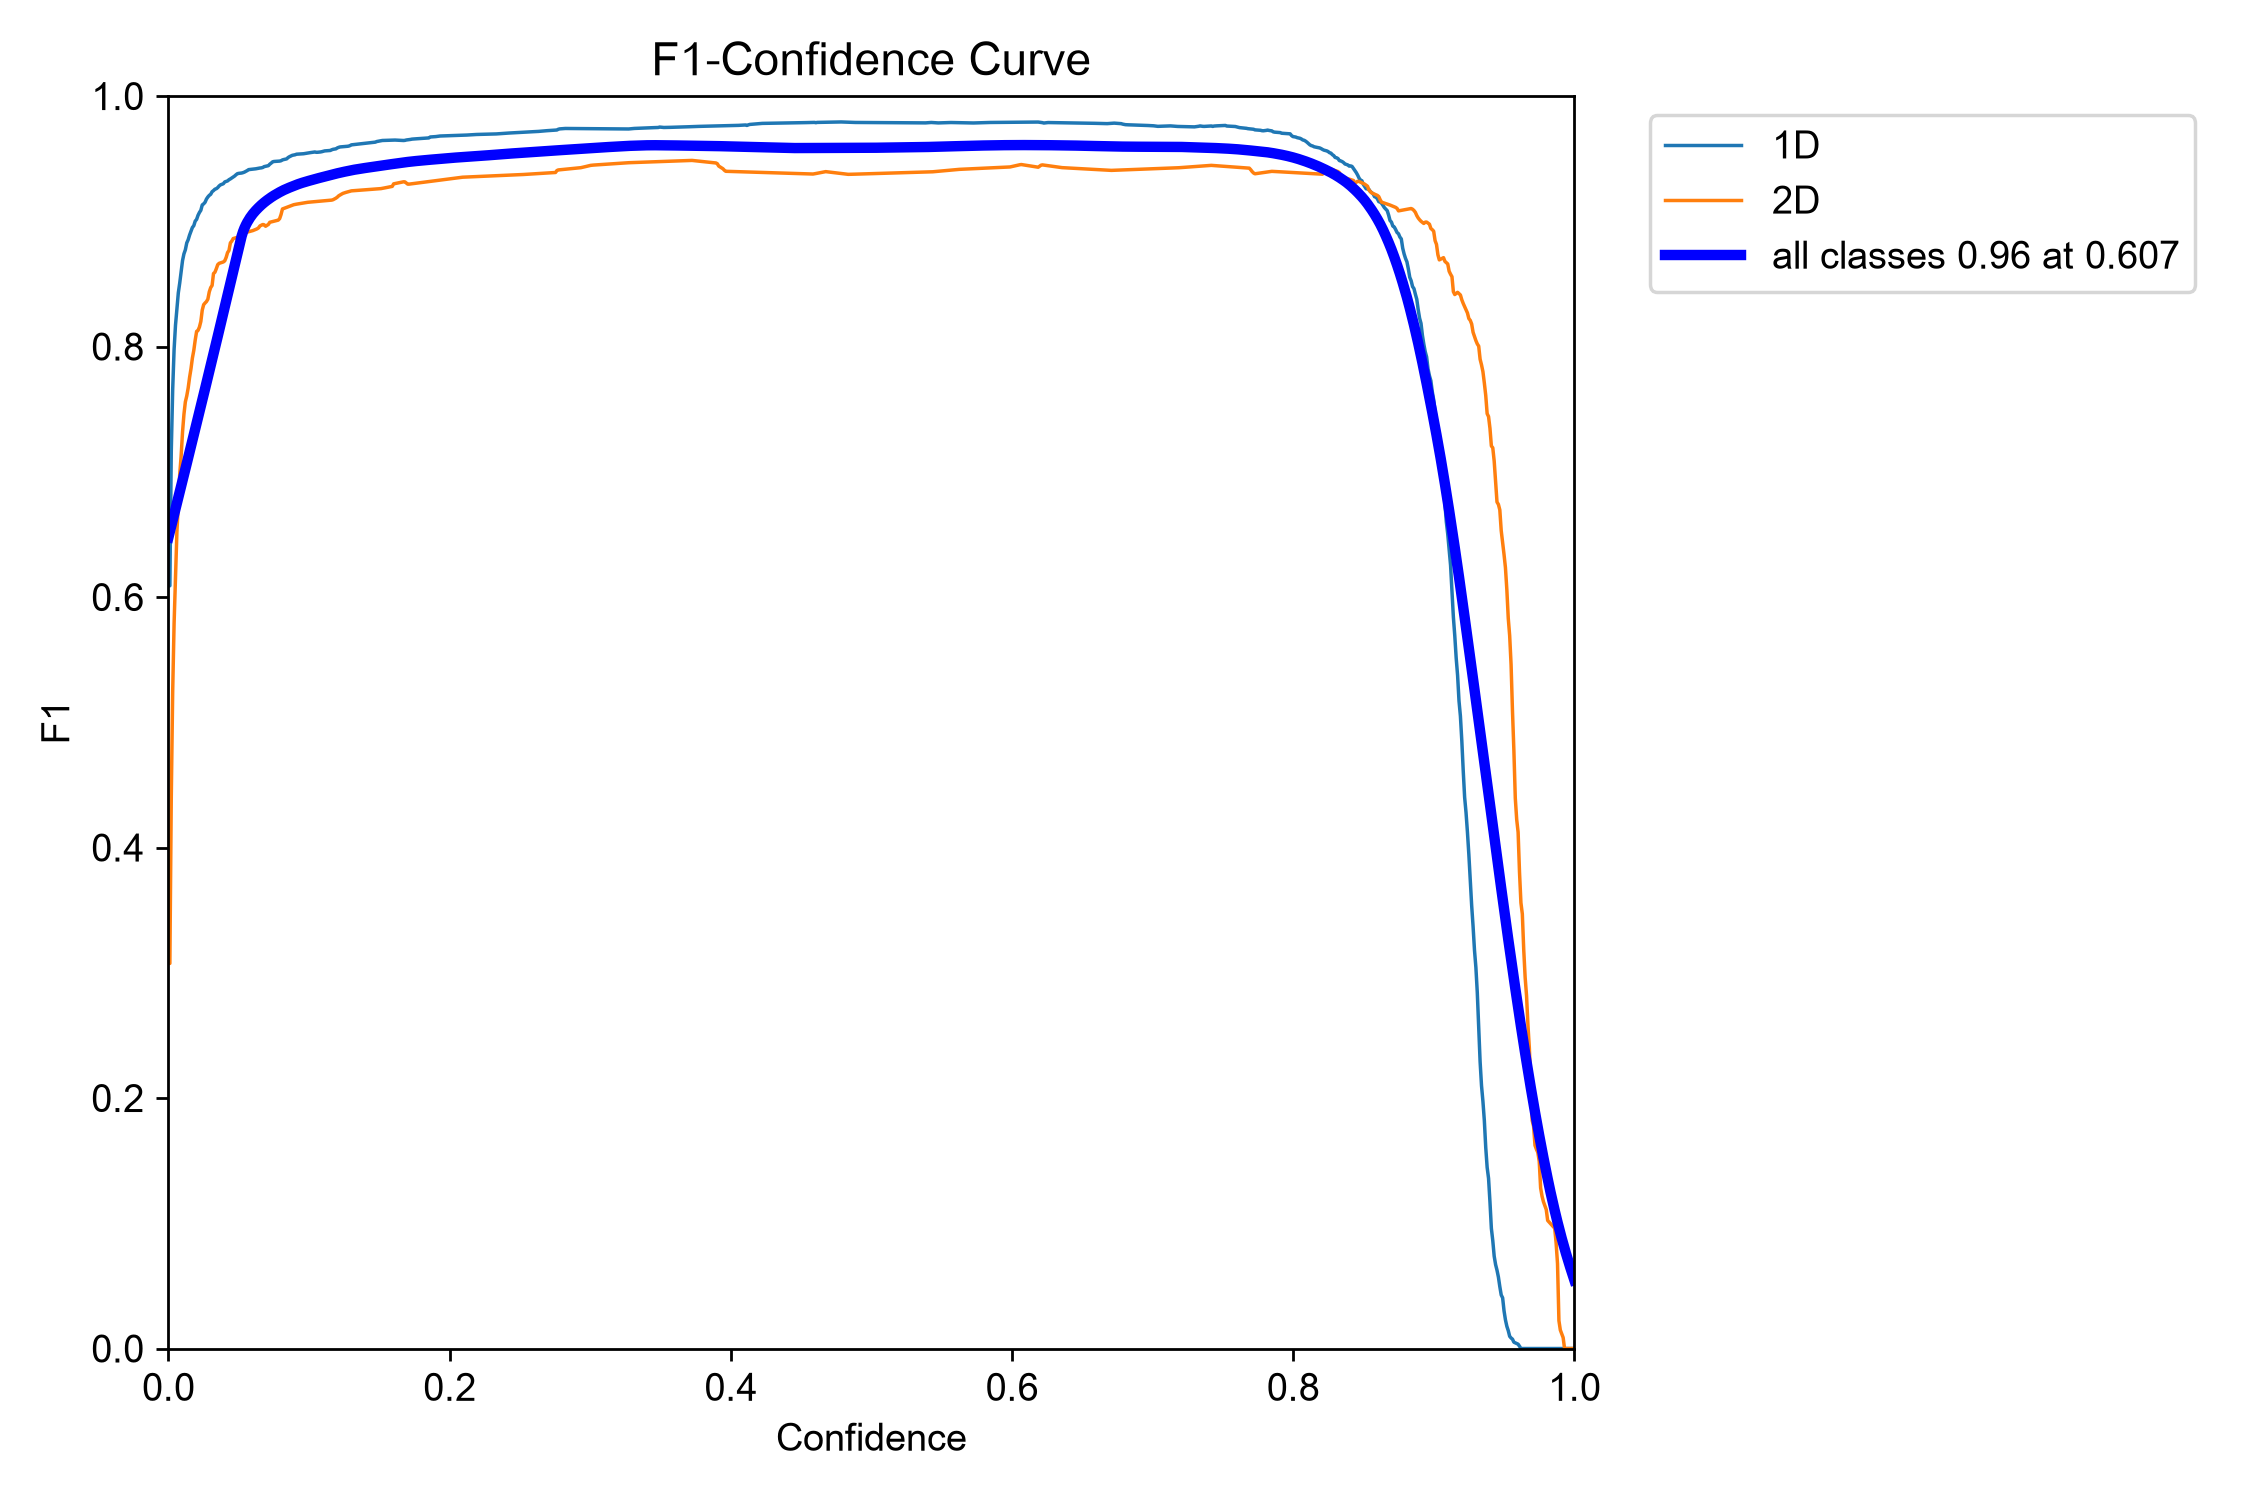


📊 confusion_matrix.png


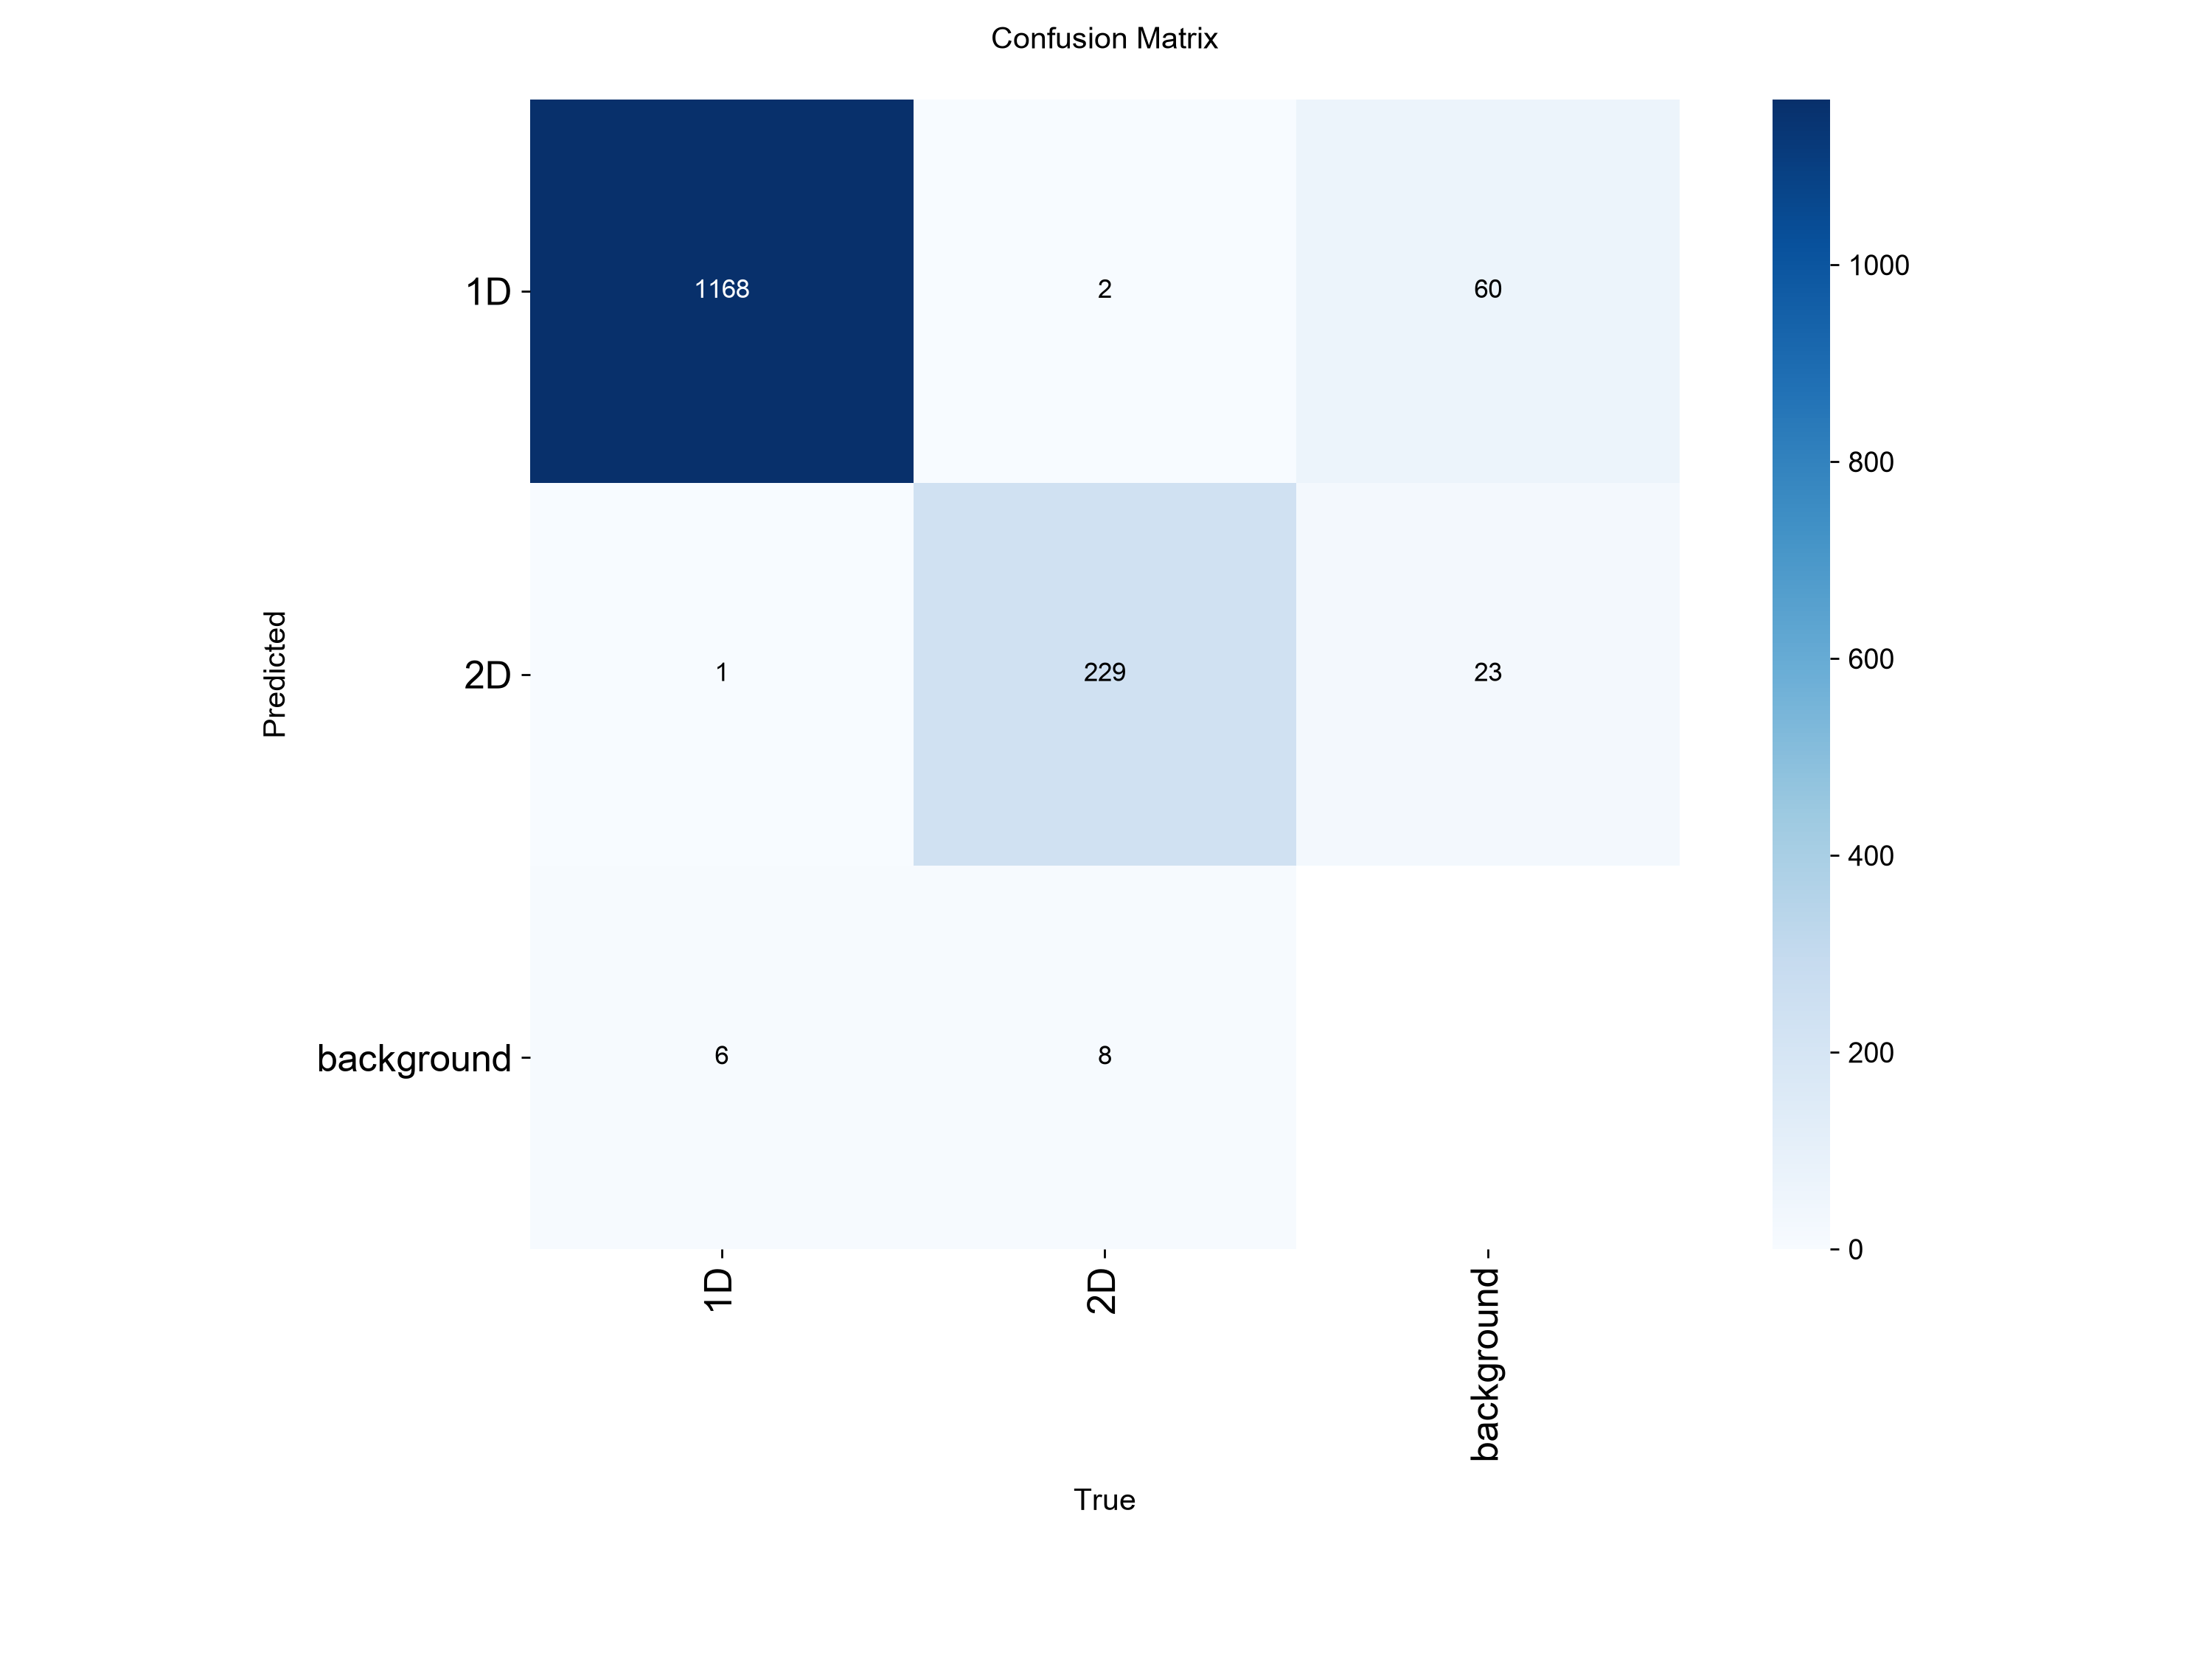


📊 results.png


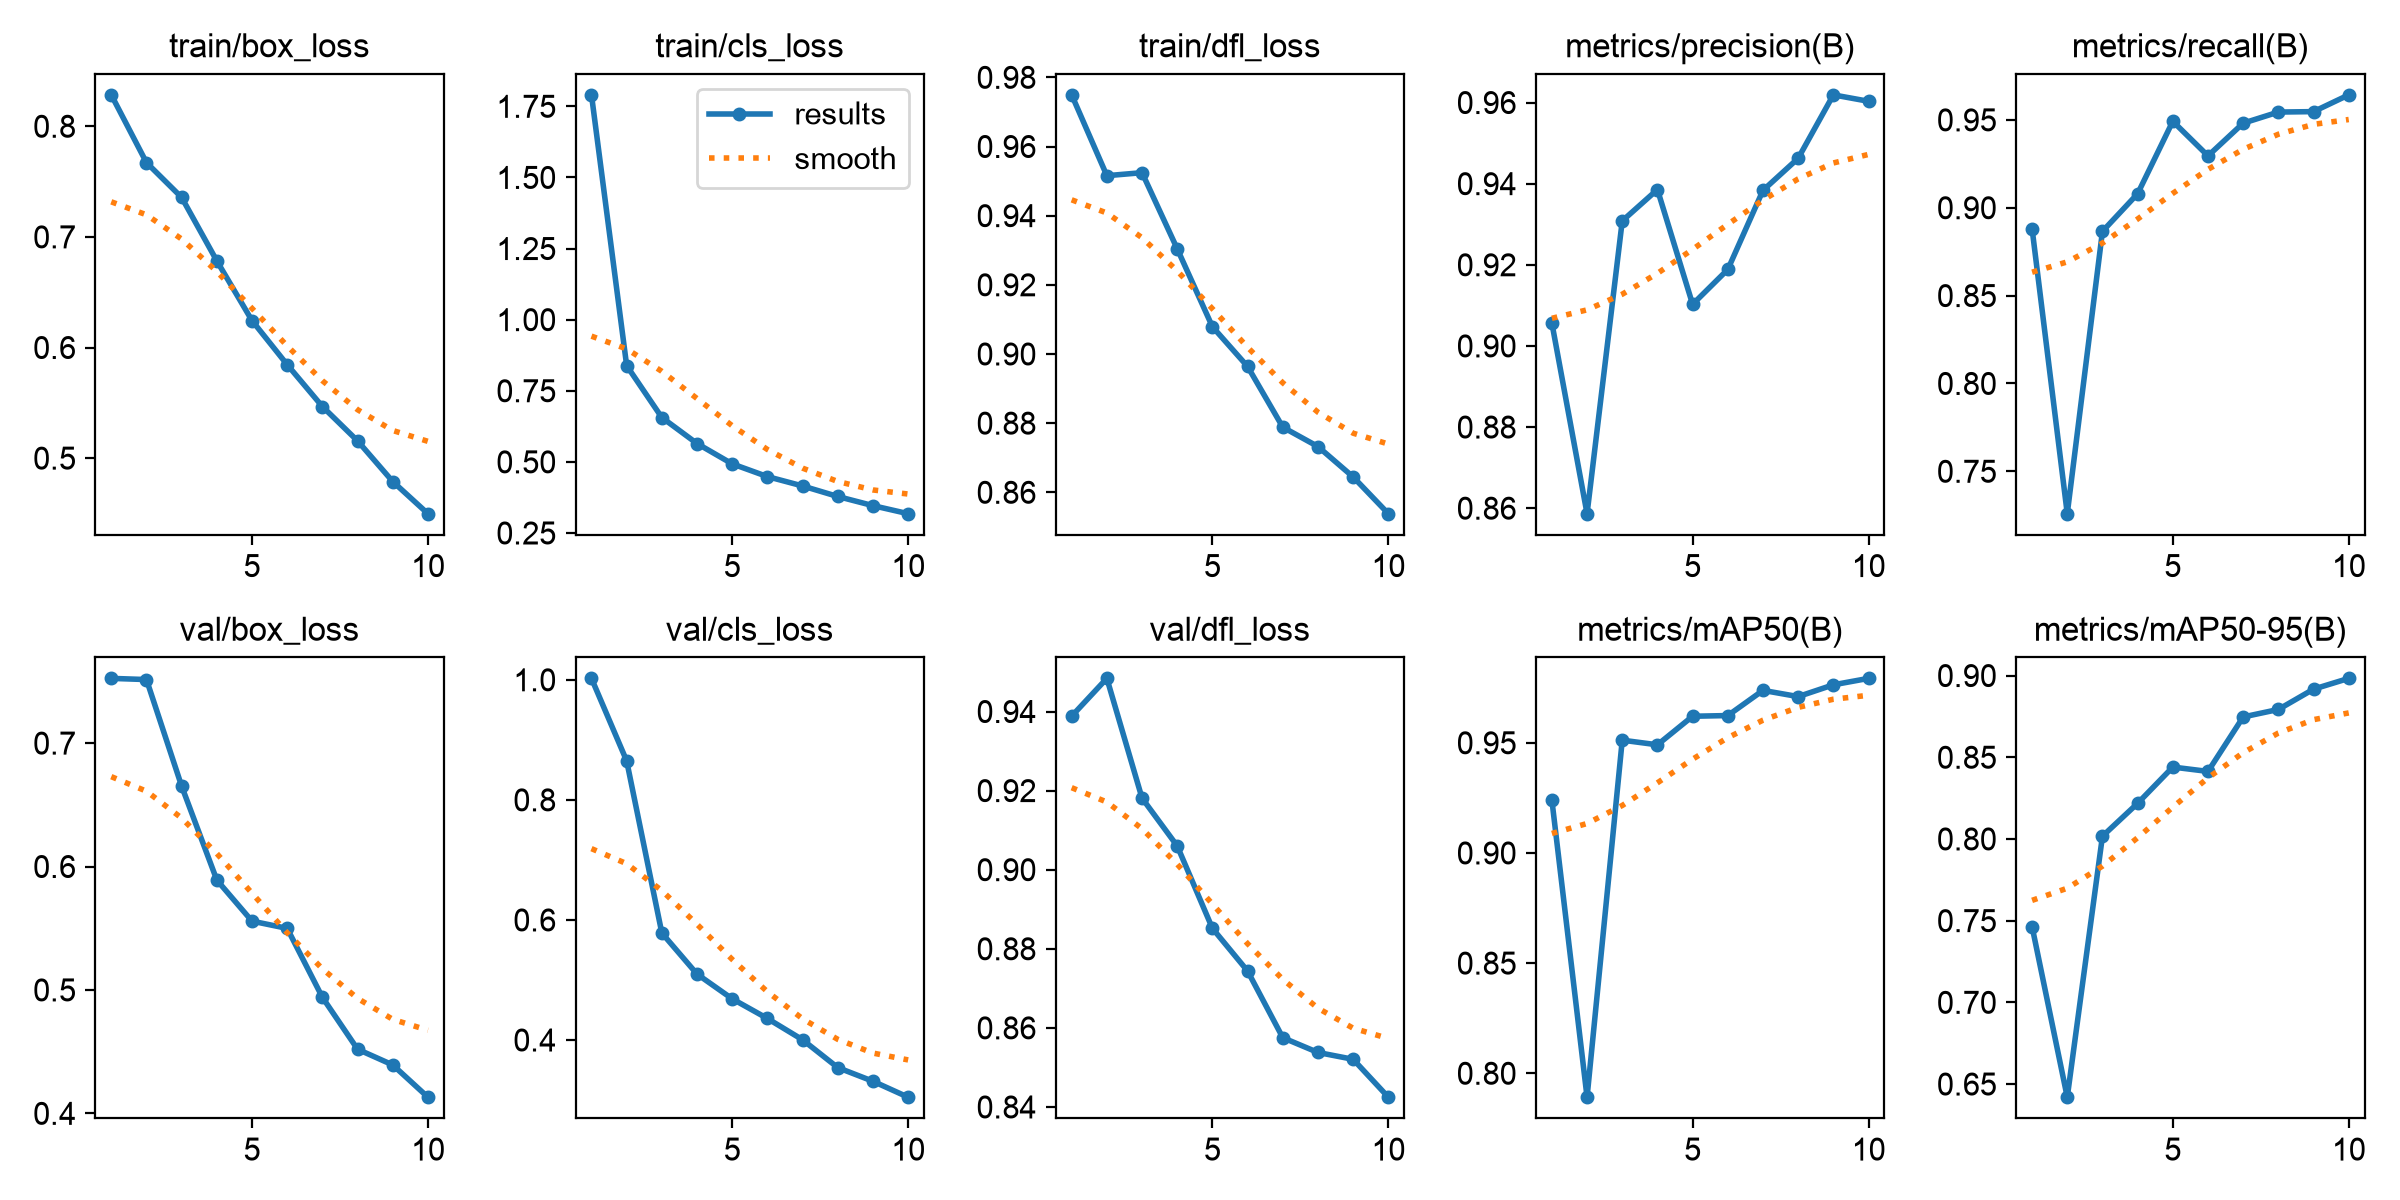

In [26]:
from IPython.display import display, Image
from pathlib import Path

# Path to the results folder
results_folder = Path("/Users/israelm/Desktop/DATA SCIENCE/runs/detect/train-3")

# List of plots to display
plots = [
    "BoxPR_curve.png",      # Precision-Recall curve
    "BoxP_curve.png",       # Precision vs Confidence
    "BoxR_curve.png",       # Recall vs Confidence
    "BoxF1_curve.png",      # F1 score vs Confidence
    "confusion_matrix.png", # Confusion matrix
    "results.png"           # Training results summary
]

print("Displaying plots from training results:")
print("=" * 60)

for plot_name in plots:
    plot_path = results_folder / plot_name
    if plot_path.exists():
        print(f"\n📊 {plot_name}")
        display(Image(filename=str(plot_path), width=600))
    else:
        print(f"\n⚠️ {plot_name} not found")

---

## Adding More Sample Predictions with Bounding Boxes

To further validate the detection model, I will display additional sample predictions from the test set with bounding boxes.

### Code

Found 1284 validation images

image 1/1 /Users/israelm/Desktop/DATA SCIENCE/1. NOW/3.DEEP LEARNING 1 /BarBeR-Project/data/raw/dataset/images/val/4823085721266.jpg: 640x352 1 1D, 19.1ms
Speed: 0.9ms preprocess, 19.1ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 352)

image 1/1 /Users/israelm/Desktop/DATA SCIENCE/1. NOW/3.DEEP LEARNING 1 /BarBeR-Project/data/raw/dataset/images/val/7392254483498-01.jpg: 480x640 1 1D, 34.1ms
Speed: 2.7ms preprocess, 34.1ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /Users/israelm/Desktop/DATA SCIENCE/1. NOW/3.DEEP LEARNING 1 /BarBeR-Project/data/raw/dataset/images/val/QR-photo_26_0072.jpg: 384x640 2 1Ds, 1 2D, 22.4ms
Speed: 1.1ms preprocess, 22.4ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /Users/israelm/Desktop/DATA SCIENCE/1. NOW/3.DEEP LEARNING 1 /BarBeR-Project/data/raw/dataset/images/val/4008617681014-01_N95.jpg: 512x640 1 1D, 24.9ms
Speed: 0.7ms preprocess, 24.9ms infe

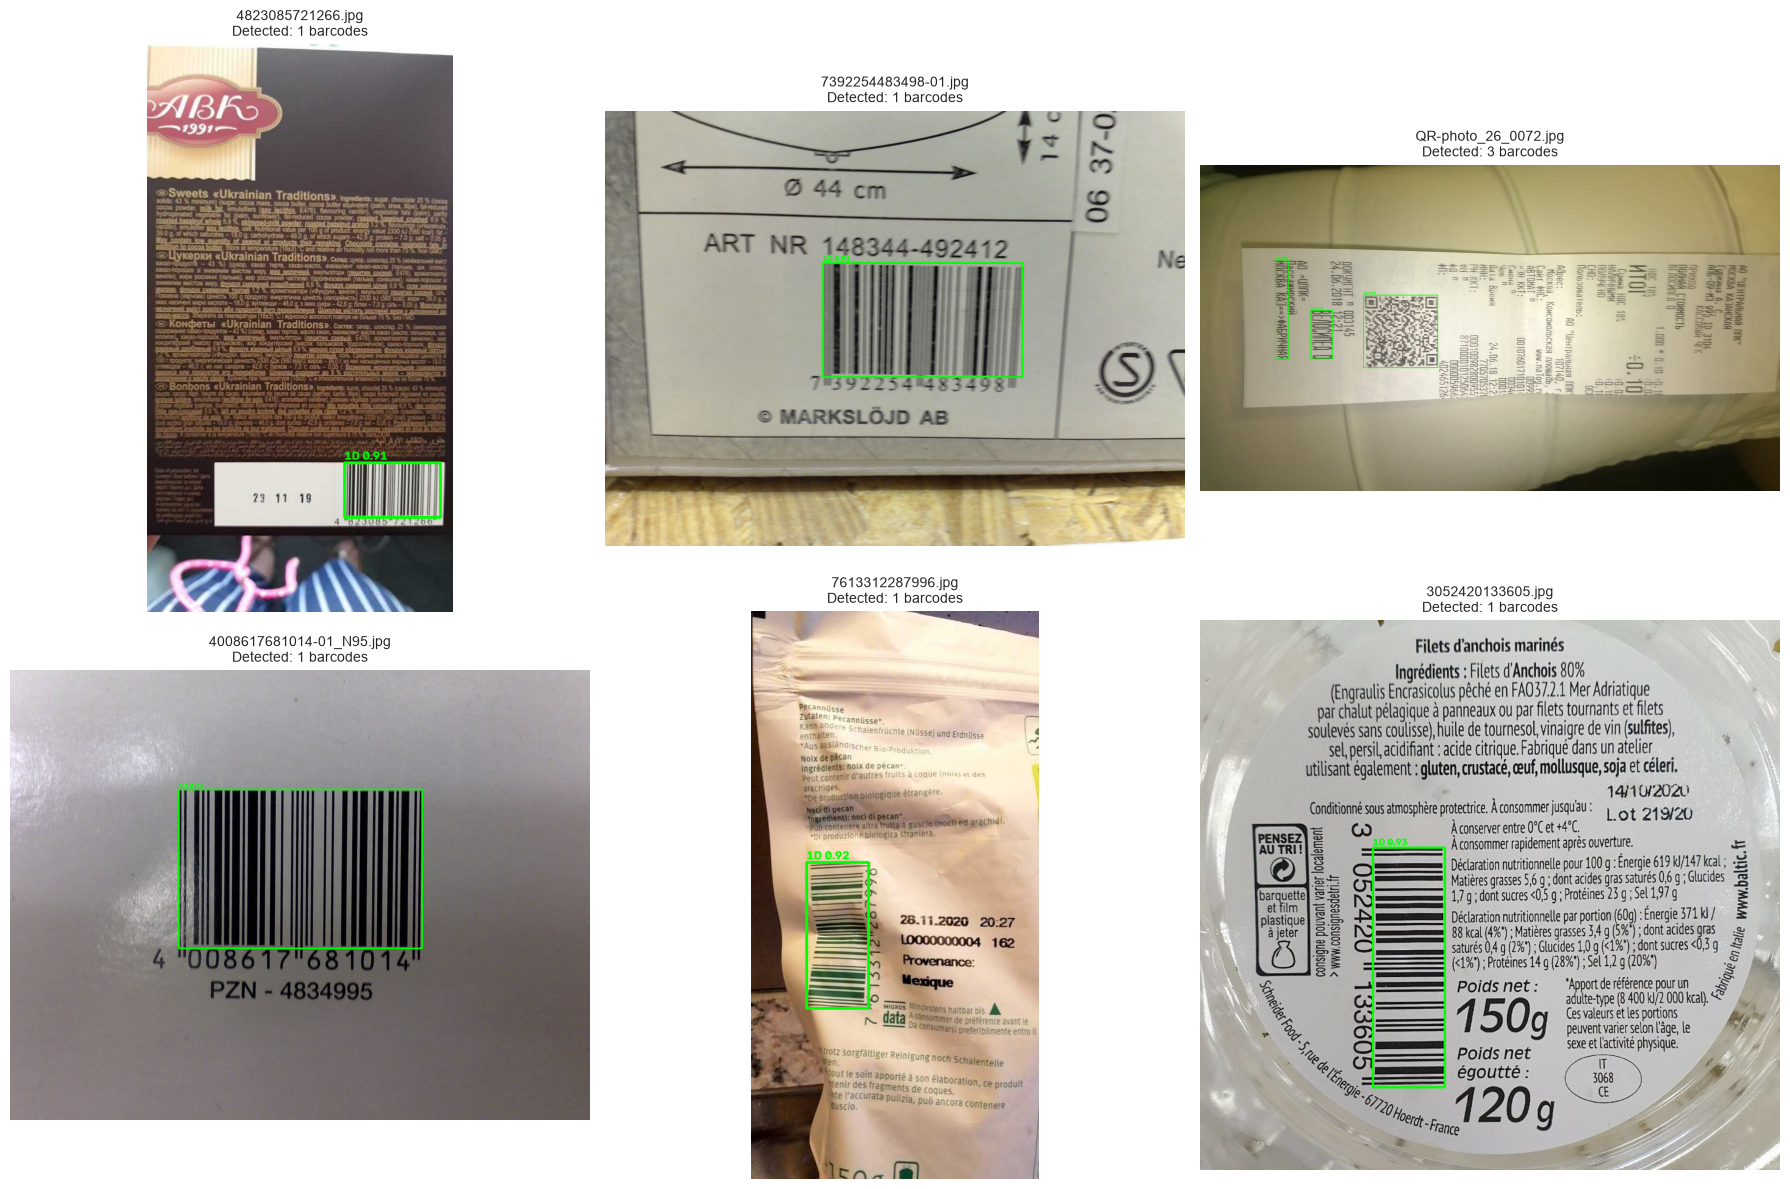

In [23]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

# Define paths
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset"

# Load the model
model = YOLO("/Users/israelm/Desktop/DATA SCIENCE/runs/detect/train-3/weights/best.pt")

# Get validation images (they exist in the val folder)
val_img_dir = DATA_PATH / "images" / "val"
val_images = list(val_img_dir.glob("*.jpg"))

print(f"Found {len(val_images)} validation images")

# Randomly select 6 images
sample_files = random.sample(val_images, min(6, len(val_images)))

# Display predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_path in enumerate(sample_files):
    # Run inference
    results = model(img_path)
    
    # Load image
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw bounding boxes and labels
    for box in results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls = int(box.cls[0].item())
        label = f"{model.names[cls]} {conf:.2f}"
        cv2.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 3)
        cv2.putText(img_rgb, label, (int(x1), int(y1)-5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"{img_path.name}\nDetected: {len(results[0].boxes)} barcodes", fontsize=10)
    axes[idx].axis('off')

# Hide any unused subplots
for idx in range(len(sample_files), 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

---

## Section 5: Model Comparison

To evaluate which approach performs better, I will compare the classification and detection models side by side.

### Code


In [6]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Task Type', 'Final Test Score', 'Training Time (approx)', 'Model Size'],
    'BasicCNN': ['Classification', f"{classification_final['test_accuracy']}% (Accuracy)", '~26 minutes', 'Small (~2MB)'],
    'YOLOv8n': ['Detection', f"{detection_results['test_mAP50']}% (mAP50)", '~3.4 hours', '~6.2MB']
})

print("Model Comparison Summary")
print("=" * 60)
print(comparison_df.to_string(index=False))

Model Comparison Summary
                Metric          BasicCNN        YOLOv8n
             Task Type    Classification      Detection
      Final Test Score 96.34% (Accuracy) 97.93% (mAP50)
Training Time (approx)       ~26 minutes     ~3.4 hours
            Model Size      Small (~2MB)         ~6.2MB


---

## Section 6: Discussion

This section provides the interpretation of results, limitations, and suggestions for future work as required by the professor.

Discussion
============================================================

1. Methodology:
   - The project successfully implemented two approaches on the BarBeR dataset:
     a) BasicCNN for binary classification (1D vs 2D barcodes)
     b) YOLOv8n for object detection (bounding boxes + class labels)
   - The dataset was preprocessed from VIA JSON format to YOLO format
   - Both models were trained on a MacBook Air M4 (CPU)

2. Results Interpretation:
   - The BasicCNN achieved 96.34% test accuracy, demonstrating that 1D vs 2D 
     classification is relatively straightforward.
   - The YOLOv8n model achieved 97.93% mAP50, successfully reproducing the 
     detection task from the BarBeR paper.
   - 1D barcodes (99.3% mAP50) are detected more accurately than 2D barcodes 
     (96.6% mAP50), likely due to class imbalance.

3. Comparison to the Paper:
   - The paper reports detection results using various methods including YOLO.
   - Our YOLOv8n results (97.9% mAP50) are comparable to the paper's findings,
     confirming the reproducibility of the BarBeR benchmark.
   - The simplified classification task serves as a baseline for future work.


## Limitations, Challenges, and Future Work

### Limitations

1. **Dataset Imbalance:** The BarBeR dataset contains significantly more 1D barcodes (82%) than 2D barcodes (18%), which may have biased the model toward 1D detection and classification.

2. **Limited Training Epochs:** Due to time constraints, both models were trained for only 10 epochs. While performance was strong, additional epochs could potentially improve accuracy further.

3. **CPU-Only Training:** Training was conducted on a MacBook Air M4 CPU. While functional, this limited batch size and slowed training, especially for the YOLOv8n model which took approximately 3.4 hours.

4. **Corrupted Images:** Several images in the dataset were corrupted or truncated, requiring handling via `ImageFile.LOAD_TRUNCATED_IMAGES` and verification steps during loading.

5. **Classification Model Not Saved:** The classification model weights were not saved during the initial training, preventing the generation of a confusion matrix and further analysis.

6. **Test Split Issues:** The test split was not properly configured during data reorganization, requiring workarounds using the validation set for final evaluation.

---

### Challenges Faced and Methods of Solving

**Challenge 1: Converting VIA JSON Annotations to YOLO Format**

The dataset annotations were in VIA JSON format with polygon coordinates, not YOLO's normalized bounding box format. To solve this, a custom conversion script was written that extracted polygon points, calculated bounding boxes, normalized them to values between 0 and 1, and saved them as YOLO `.txt` files.

**Challenge 2: Dataset Reorganization for YOLO Compatibility**

YOLO expects a specific folder structure with `images/train/`, `images/val/`, `labels/train/`, and `labels/val/` subdirectories. The required folder structure was created and files were moved according to train/val/test splits using Python's `shutil` library.

**Challenge 3: Path and File Handling Errors**

YOLO could not find label files due to incorrect paths in `data.yaml` and `train.txt`. All paths were carefully verified, `data.yaml` was updated with correct relative paths, and `train.txt` and `val.txt` were ensured to contain only bare filenames.

**Challenge 4: Handling Corrupted Images**

Several images in the dataset were truncated or corrupted, causing loading errors. This was resolved using `ImageFile.LOAD_TRUNCATED_IMAGES = True` and adding try-except blocks to skip corrupted files during dataset creation.

**Challenge 5: Mismatched Images and Labels**

After reorganization, there was a mismatch between image and label counts (e.g., 6020 images vs 6131 labels). Images without labels and labels without corresponding images were identified and removed, ensuring a one-to-one match.

---

### Future Work

1. **Extended Training:** Train both models for more epochs (e.g., 50-100) to determine if performance continues to improve and to observe overfitting behavior.

2. **Transfer Learning:** Implement MobileNetV2 or EfficientNet-B0 as backbones for both classification and detection tasks, as recommended by the professor.

3. **GPU Acceleration:** Use Google Colab or a local GPU to accelerate training, allowing for larger batch sizes and faster experimentation.

4. **Multi-Class Detection:** Extend the detection task beyond binary (1D vs 2D) to classify specific barcode types such as EAN13, QR, PDF417, and DATAMATRIX.

5. **Data Augmentation:** Experiment with additional augmentation techniques (rotation, scaling, brightness) to improve model generalization.

6. **Model Comparison:** Compare additional architectures such as SSD, Faster R-CNN, and other YOLO variants (YOLOv5, YOLOv9, YOLOv11) on the BarBeR dataset.

7. **Hyperparameter Tuning:** Perform systematic hyperparameter optimization (learning rate, batch size, optimizer) to maximize performance.

8. **Deployment:** Package the trained model for real-time barcode detection in mobile or embedded applications.

9. **Save Model Weights:** Ensure all trained models are properly saved with `torch.save()` for future reproducibility and analysis.

---

## Section 7: Conclusion

To conclude the project, I will summarize the key findings and contributions.

Conclusion
============================================================

This project successfully reproduced the detection task from the BarBeR paper 
by training a YOLOv8n model on the BarBeR dataset, achieving 97.93% mAP50. 
Additionally, a BasicCNN was trained for binary classification, achieving 
96.34% test accuracy, serving as a baseline.

The results demonstrate that:
- The BarBeR dataset is suitable for both classification and detection tasks.
- Lightweight architectures (BasicCNN, YOLOv8n) can achieve strong performance.
- The YOLOv8n model successfully reproduces the paper's detection task.

The project provides a complete pipeline for data preprocessing, model training, 
and evaluation on the BarBeR dataset, with both classification and detection 
approaches available for future benchmarking.


✅ Project completed successfully!